# Brain Activation Analysis — Per-Channel HbO (HC vs GAD, GNG task)

**Purpose:** Statistical comparison of per-channel HbO activation between HC and GAD on the **GNG (Go/No-Go) task**. Provides neurophysiological evidence supporting the use of GNG-derived HbO features in the downstream graph models.

**Reference:** Methodology mirrors `references/analysis/notebook/statistical-analysis/02_brain_activation/02_brain_activation_anova.ipynb` (Wang et al. 2025-style channel-level analysis), restricted to the single GNG task that exists in `data/processed-new-mc/`.

**Cohort (GNG):** HC n=33, GAD n=29 (defined by folders under `data/processed-new-mc/GNG/`).

**Activation metric:** Per-channel **STD** of the concatenated HbO trials (4 trials × 326 frames → 1304 samples per channel). For zero-mean preprocessed signals this STD is equivalent to RMS amplitude.

**Tests:**
- Shapiro-Wilk normality check on representative channels.
- Per-channel Mann-Whitney U (two-sided), HC vs GAD.
- Benjamini-Hochberg FDR correction (q=0.05) across the 23 channels.
- Cohen's d effect size (positive = GAD > HC).

> **Note:** Demographic differences (age, sex) between HC and GAD are reported in `01_demographic`. Brain-activation differences should be interpreted in light of those demographic imbalances.

## 1. Imports & Configuration

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import mannwhitneyu, shapiro, ttest_ind
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..', '..'))
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data', 'processed-new-mc')
TASK         = 'GNG'
OUT_DIR      = os.path.join(PROJECT_ROOT, 'src', 'notebook', 'statistical-analysis', '02_brain_activation')
os.makedirs(OUT_DIR, exist_ok=True)
print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'DATA_DIR     = {DATA_DIR}')
print(f'OUT_DIR      = {OUT_DIR}')


PROJECT_ROOT = /home/user/jeffrymahbuubi/PROJECTS/2-fNIRS-Graph-Base-Method
DATA_DIR     = /home/user/jeffrymahbuubi/PROJECTS/2-fNIRS-Graph-Base-Method/data/processed-new-mc
OUT_DIR      = /home/user/jeffrymahbuubi/PROJECTS/2-fNIRS-Graph-Base-Method/src/notebook/statistical-analysis/02_brain_activation


## 2. Channel Mapping (23 Channels → 5×7 Grid)

In [2]:
CHANNEL_NAMES = [
    'S1_D1', 'S1_D3', 'S2_D2', 'S2_D1', 'S2_D5',
    'S3_D1', 'S3_D3', 'S3_D4', 'S3_D6',
    'S4_D4', 'S4_D5', 'S4_D7',
    'S5_D2', 'S5_D5', 'S5_D8',
    'S6_D3', 'S6_D6',
    'S7_D4', 'S7_D6', 'S7_D7',
    'S8_D5', 'S8_D7', 'S8_D8',
]
GRID_POS = [
    (0,2), (1,1), (0,4), (0,3), (1,4),
    (1,2), (2,1), (2,2), (3,1),
    (2,3), (2,4), (3,4),
    (1,5), (2,5), (3,6),
    (3,0), (4,1),
    (3,2), (4,2), (4,3),
    (3,5), (4,4), (4,5),
]
GRID_SHAPE = (5, 7)
N_CH       = len(CHANNEL_NAMES)
CH_TO_IDX  = {ch: i for i, ch in enumerate(CHANNEL_NAMES)}

def values_to_grid(values, fill=np.nan):
    g = np.full(GRID_SHAPE, fill, dtype=float)
    for i, (r, c) in enumerate(GRID_POS):
        g[r, c] = values[i]
    return g

print(f'{N_CH} channels on a {GRID_SHAPE[0]}×{GRID_SHAPE[1]} grid.')


23 channels on a 5×7 grid.


## 3. Load Subject HbO Activations

In [3]:
HC_IDS  = sorted(os.listdir(os.path.join(DATA_DIR, TASK, 'healthy')))
GAD_IDS = sorted(os.listdir(os.path.join(DATA_DIR, TASK, 'anxiety')))
print(f'HC  (n={len(HC_IDS)}): {HC_IDS}')
print(f'GAD (n={len(GAD_IDS)}): {GAD_IDS}')

def load_subject_activation(subject_id, task, group, hb='hbo'):
    """Per-channel STD across concatenated trials. Returns (23,) array."""
    path  = os.path.join(DATA_DIR, task, group, subject_id, hb)
    files = sorted(os.listdir(path))
    if len(files) == 0:
        raise RuntimeError(f'No trials in {path}')
    concat = np.concatenate([np.load(os.path.join(path, f)) for f in files], axis=1)
    assert concat.shape[0] == N_CH, f'Expected 23 channels, got {concat.shape[0]} for {subject_id}'
    return concat.std(axis=1)

# activations[group] -> (n_subj, 23)
activations = {
    'HC' : np.array([load_subject_activation(s, TASK, 'healthy') for s in HC_IDS]),
    'GAD': np.array([load_subject_activation(s, TASK, 'anxiety') for s in GAD_IDS]),
}
print()
print(f"HC  activations : shape={activations['HC'].shape},  mean={activations['HC'].mean():.4g}")
print(f"GAD activations : shape={activations['GAD'].shape}, mean={activations['GAD'].mean():.4g}")


HC  (n=33): ['AH014', 'AH015', 'AH017', 'AH018', 'AH019', 'AH020', 'AH021', 'AH022', 'AH023', 'AH024', 'AH025', 'AH026', 'AH027', 'AH028', 'AH029', 'AH030', 'AH031', 'AH033', 'AH034', 'AH035', 'AH036', 'AH037', 'AH038', 'AH039', 'AH040', 'AH043', 'AH044', 'AH045', 'AH046', 'AH047', 'AH048', 'AH049', 'AH050']
GAD (n=29): ['AA011', 'AA013', 'AA041', 'AA056', 'AA064', 'AA089', 'AA090', 'AA092', 'AA093', 'AA094', 'AA097', 'AA098', 'AA099', 'EA055', 'EA060', 'EA061', 'EA062', 'LA042', 'LA051', 'LA052', 'LA053', 'LA054', 'LA057', 'LA058', 'LA059', 'LA063', 'LA091', 'LA095', 'LA096']

HC  activations : shape=(33, 23),  mean=0.9031
GAD activations : shape=(29, 23), mean=0.8863


## 4. Normality Check (Shapiro-Wilk)

In [4]:
sample_channels = [0, 11, 22]  # first, middle, last
print('=== Shapiro-Wilk normality test (HbO activation, GNG) ===')
print(f'{"Channel":<10} {"HC p":>10} {"GAD p":>10} {"Verdict":>14}')
print('-' * 48)
for ch in sample_channels:
    _, p_hc  = shapiro(activations['HC'][:, ch])
    _, p_gad = shapiro(activations['GAD'][:, ch])
    verdict = 'normal' if (p_hc > 0.05 and p_gad > 0.05) else 'non-normal'
    print(f'{CHANNEL_NAMES[ch]:<10} {p_hc:>10.4f} {p_gad:>10.4f} {verdict:>14}')
print()
print('Conclusion: prefer the non-parametric Mann-Whitney U test (matches reference notebook).')


=== Shapiro-Wilk normality test (HbO activation, GNG) ===
Channel          HC p      GAD p        Verdict
------------------------------------------------
S1_D1          0.0042     0.8756     non-normal
S4_D7          0.1095     0.2123         normal
S8_D8          0.2146     0.1814         normal

Conclusion: prefer the non-parametric Mann-Whitney U test (matches reference notebook).


## 5. Per-Channel Mann-Whitney U + FDR Correction

In [5]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    s = np.sqrt(((na-1)*a.std(ddof=1)**2 + (nb-1)*b.std(ddof=1)**2) / (na+nb-2))
    return (b.mean() - a.mean()) / s if s > 0 else 0.0  # +ve => GAD > HC

hc  = activations['HC']
gad = activations['GAD']

rows, p_raw = [], []
for ch in range(N_CH):
    a = hc[:, ch]; b = gad[:, ch]
    U, p = mannwhitneyu(a, b, alternative='two-sided')
    rows.append({
        'channel': CHANNEL_NAMES[ch],
        'mean_hc' : a.mean(), 'std_hc' : a.std(ddof=1),
        'mean_gad': b.mean(), 'std_gad': b.std(ddof=1),
        'U': U, 'p_raw': p, 'd': cohens_d(a, b),
    })
    p_raw.append(p)

reject_fdr, p_fdr, _, _ = multipletests(p_raw, alpha=0.05, method='fdr_bh')

stats_df = pd.DataFrame(rows)
stats_df['p_fdr']    = p_fdr
stats_df['sig_raw']  = stats_df['p_raw'] < 0.05
stats_df['sig_fdr']  = reject_fdr

print(f'Channels p<0.05 (uncorrected) : {stats_df["sig_raw"].sum()}/{N_CH}')
print(f'Channels q<0.05 (FDR)         : {stats_df["sig_fdr"].sum()}/{N_CH}')
print()

sig_only = stats_df[stats_df['sig_raw']].sort_values('p_raw').copy()
if len(sig_only):
    sig_only['Δ (GAD−HC)'] = sig_only['mean_gad'] - sig_only['mean_hc']
    print(sig_only[['channel','mean_hc','std_hc','mean_gad','std_gad','Δ (GAD−HC)','d','U','p_raw','p_fdr','sig_fdr']]
          .to_string(index=False, float_format=lambda x: f'{x:.4g}'))
else:
    print('  No channels reach uncorrected p<0.05 in this cohort.')


Channels p<0.05 (uncorrected) : 10/23
Channels q<0.05 (FDR)         : 4/23

channel  mean_hc  std_hc  mean_gad  std_gad  Δ (GAD−HC)       d   U     p_raw   p_fdr  sig_fdr
  S5_D5   0.9175 0.03155    0.8849  0.03952    -0.03262 -0.9191 715 0.0008701 0.01391     True
  S2_D1   0.9128 0.03185    0.8768  0.04557    -0.03593 -0.9248 707  0.001297 0.01391     True
  S3_D3   0.9101 0.03637     0.883  0.03431     -0.0271 -0.7652 695  0.002309 0.01391     True
  S1_D1   0.9083 0.04389    0.8684  0.05441     -0.0399 -0.8129 694   0.00242 0.01391     True
  S3_D4   0.8927 0.04476     0.865  0.04113    -0.02771 -0.6429 659    0.0111 0.05107    False
  S4_D5    0.912 0.04368    0.8825   0.0458    -0.02948 -0.6599 653    0.0141 0.05404    False
  S2_D5   0.9149 0.03915    0.8951  0.03549    -0.01973 -0.5263 641   0.02228 0.06407    False
  S2_D2    0.932 0.03266    0.9134  0.03504    -0.01861 -0.5506 641   0.02228 0.06407    False
  S3_D1   0.9108 0.03861    0.8887  0.04087    -0.02213 -0.5578 633  

## 6. Topographic Maps (Activation & Effect Size)

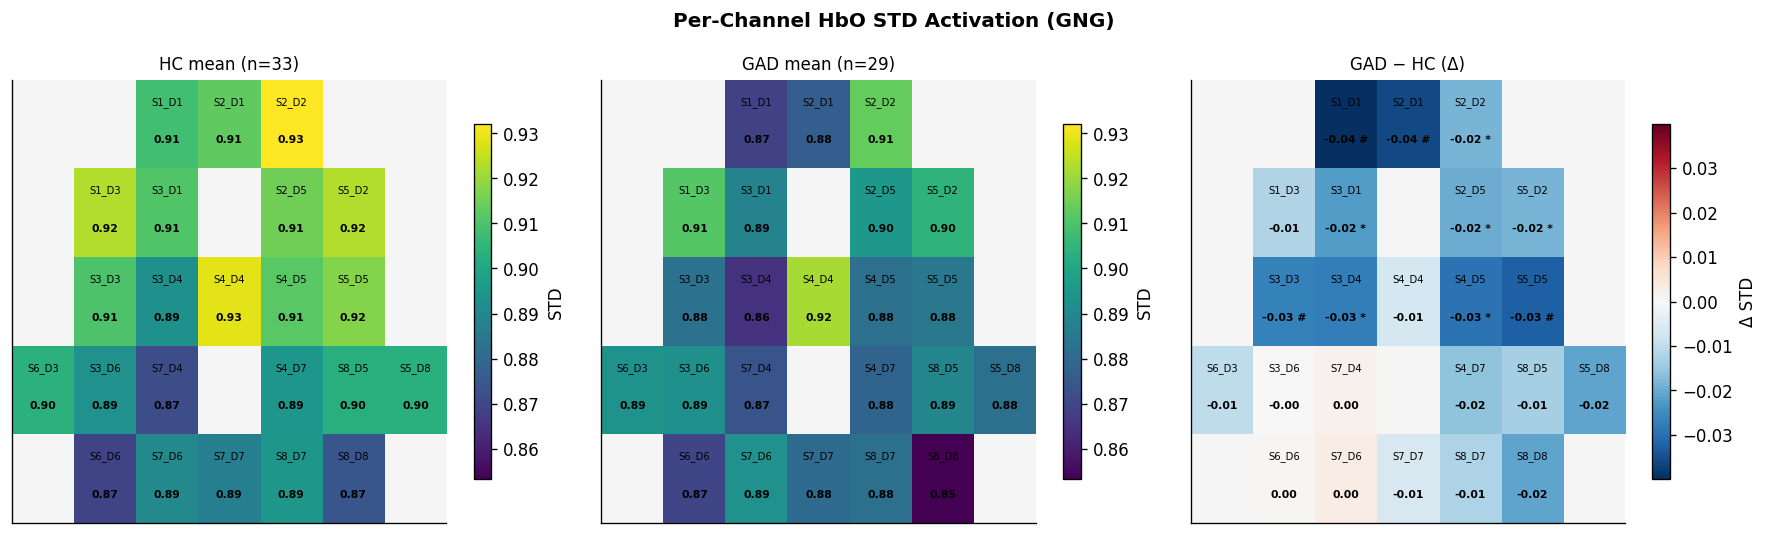

Saved: fig_topo_activation.png


In [6]:
def plot_topo(ax, values, title, cmap='viridis', vmin=None, vmax=None,
              sig_raw=None, sig_fdr=None, channel_labels=True):
    grid = values_to_grid(values)
    occupied = ~np.isnan(grid)
    if vmin is None: vmin = np.nanmin(grid)
    if vmax is None: vmax = np.nanmax(grid)
    ax.set_facecolor('#f5f5f5')
    if cmap == 'RdBu_r':
        bound = max(abs(vmin), abs(vmax))
        norm = TwoSlopeNorm(vmin=-bound, vcenter=0, vmax=bound)
        im = ax.imshow(grid, cmap=cmap, norm=norm, aspect='auto')
    else:
        im = ax.imshow(grid, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    for i, (r, c) in enumerate(GRID_POS):
        v = values[i]
        marker = ''
        if sig_fdr is not None and sig_fdr[i]:
            marker = ' #'
        elif sig_raw is not None and sig_raw[i]:
            marker = ' *'
        if channel_labels:
            ax.text(c, r-0.25, CHANNEL_NAMES[i], ha='center', va='center', fontsize=6, color='black')
            ax.text(c, r+0.18, f'{v:.2f}{marker}', ha='center', va='center', fontsize=6.5, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=10)
    return im

# Mean activation per group
mean_hc  = hc.mean(axis=0)
mean_gad = gad.mean(axis=0)
diff_d   = stats_df['d'].values  # +ve = GAD > HC
sig_raw_arr = stats_df['sig_raw'].values
sig_fdr_arr = stats_df['sig_fdr'].values

# ── Figure 1: Topographic mean activation maps ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Per-Channel HbO STD Activation (GNG)', fontsize=12, fontweight='bold')
vmin = min(mean_hc.min(), mean_gad.min())
vmax = max(mean_hc.max(), mean_gad.max())
im0 = plot_topo(axes[0], mean_hc,  f'HC mean (n={len(HC_IDS)})',  vmin=vmin, vmax=vmax)
im1 = plot_topo(axes[1], mean_gad, f'GAD mean (n={len(GAD_IDS)})', vmin=vmin, vmax=vmax)
im2 = plot_topo(axes[2], mean_gad - mean_hc, 'GAD − HC (Δ)',
                cmap='RdBu_r', sig_raw=sig_raw_arr, sig_fdr=sig_fdr_arr)
plt.colorbar(im0, ax=axes[0], shrink=0.8, label='STD')
plt.colorbar(im1, ax=axes[1], shrink=0.8, label='STD')
plt.colorbar(im2, ax=axes[2], shrink=0.8, label='Δ STD')
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_topo_activation.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_topo_activation.png')


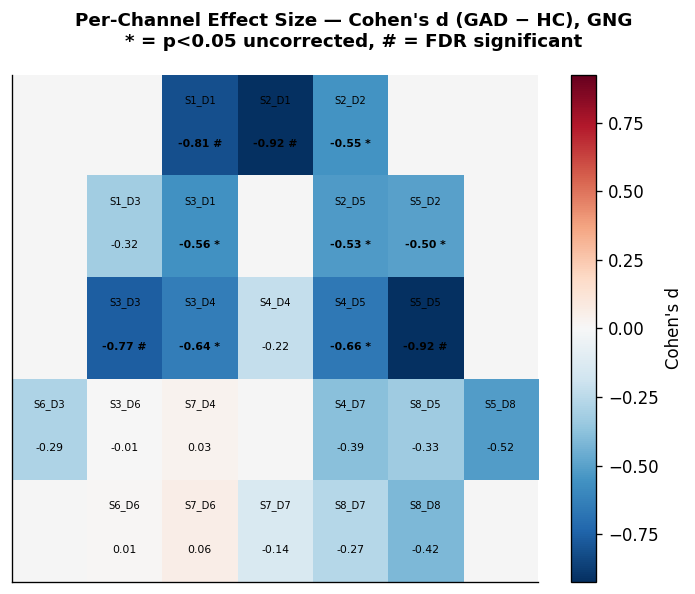

Saved: fig_topo_effect_size.png


In [7]:
# ── Figure 2: Effect-size (Cohen's d) topographic map ──
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
fig.suptitle("Per-Channel Effect Size — Cohen's d (GAD − HC), GNG\n* = p<0.05 uncorrected, # = FDR significant",
             fontsize=11, fontweight='bold')

vmax_d = max(np.abs(diff_d).max(), 0.5)
def plot_topo_d(ax, d_vals, sig_raw, sig_fdr):
    grid = values_to_grid(d_vals)
    ax.set_facecolor('#f5f5f5')
    norm = TwoSlopeNorm(vmin=-vmax_d, vcenter=0, vmax=vmax_d)
    im = ax.imshow(grid, cmap='RdBu_r', norm=norm, aspect='auto')
    for i, (r, c) in enumerate(GRID_POS):
        d_v = d_vals[i]
        marker = ''
        if sig_fdr[i]: marker = ' #'
        elif sig_raw[i]: marker = ' *'
        ax.text(c, r-0.25, CHANNEL_NAMES[i], ha='center', va='center', fontsize=6, color='black')
        ax.text(c, r+0.18, f'{d_v:.2f}{marker}', ha='center', va='center', fontsize=6.5,
                fontweight='bold' if (sig_raw[i] or sig_fdr[i]) else 'normal')
    ax.set_xticks([]); ax.set_yticks([])
    return im

im = plot_topo_d(ax, diff_d, sig_raw_arr, sig_fdr_arr)
plt.colorbar(im, ax=ax, label="Cohen's d")
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_topo_effect_size.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_topo_effect_size.png')


## 7. Channel × Significance Heatmap and Sig-Channel Bar Plots

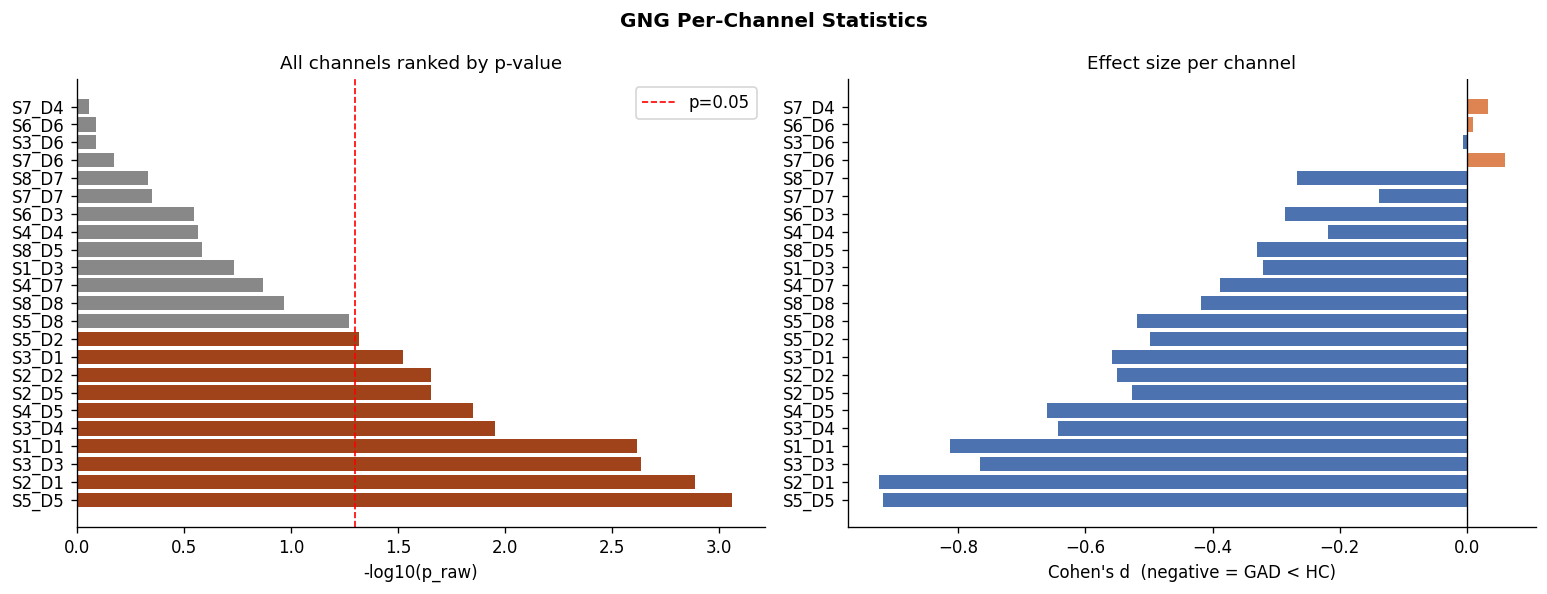

Saved: fig_channel_task_heatmap.png


In [8]:
# Channel × test heatmap (-log10 p)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('GNG Per-Channel Statistics', fontsize=12, fontweight='bold')

ax = axes[0]
order = np.argsort(stats_df['p_raw'].values)
neg_log_p = -np.log10(np.clip(stats_df['p_raw'].values, 1e-10, 1.0))
ax.barh([CHANNEL_NAMES[i] for i in order], neg_log_p[order],
        color=['#A0421A' if s else '#888' for s in stats_df['sig_raw'].values[order]])
ax.axvline(-np.log10(0.05), color='red', ls='--', lw=1, label='p=0.05')
ax.set_xlabel('-log10(p_raw)')
ax.set_title('All channels ranked by p-value')
ax.legend()

ax = axes[1]
ax.barh([CHANNEL_NAMES[i] for i in order], stats_df['d'].values[order],
        color=['#4C72B0' if d < 0 else '#DD8452' for d in stats_df['d'].values[order]])
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel("Cohen's d  (negative = GAD < HC)")
ax.set_title('Effect size per channel')

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_channel_task_heatmap.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_channel_task_heatmap.png')


Significant GNG channels (uncorrected): ['S5_D5', 'S2_D1', 'S3_D3', 'S1_D1', 'S3_D4', 'S4_D5', 'S2_D5', 'S2_D2', 'S3_D1', 'S5_D2']


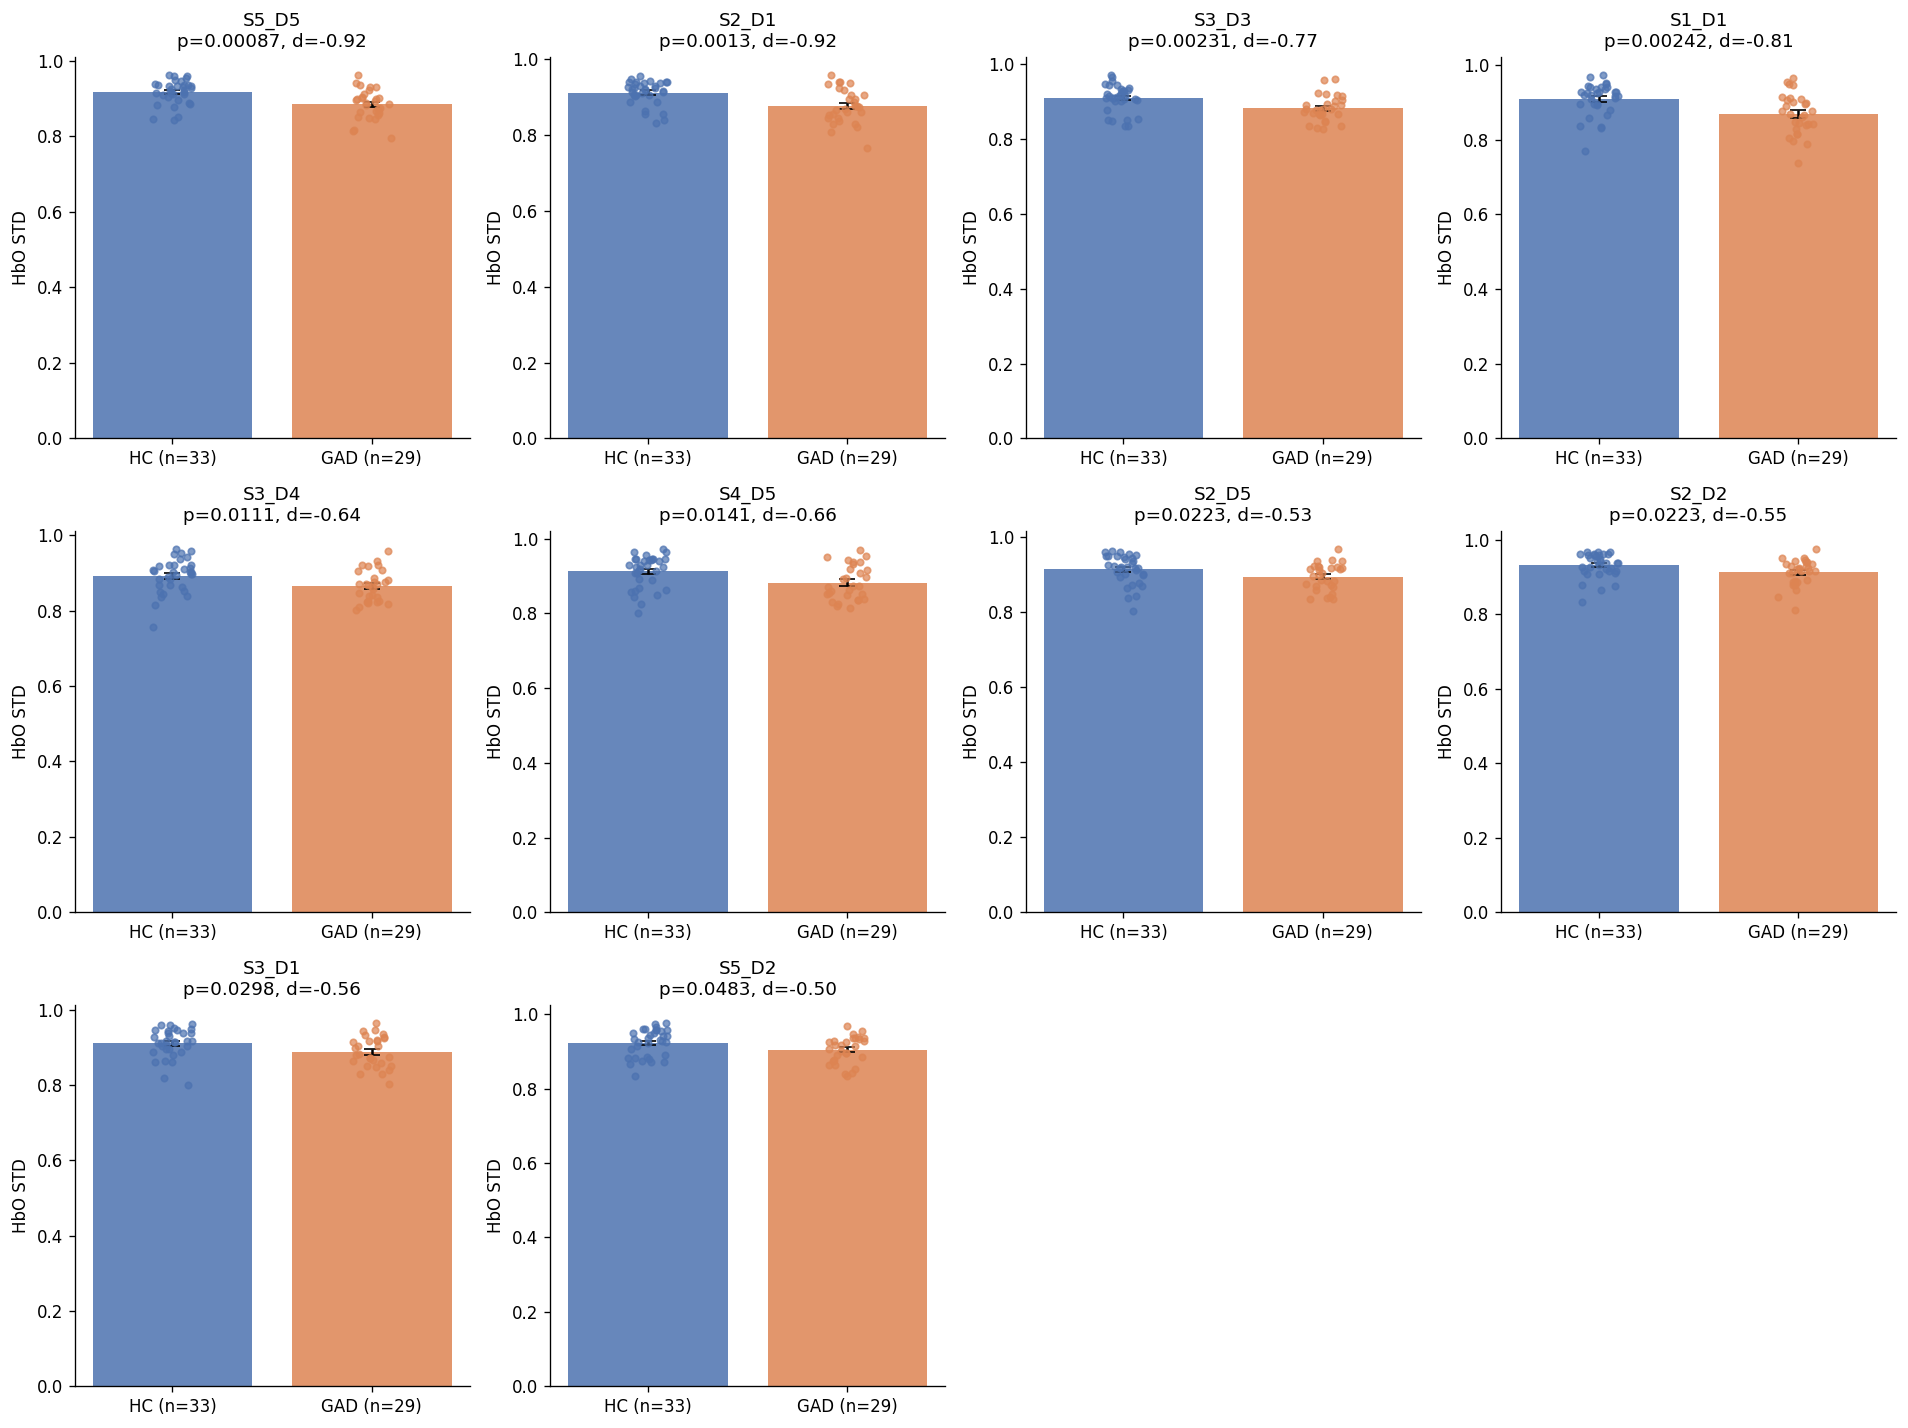

Saved: fig_gng_sig_channels.png


In [9]:
# Bar plot for the significant GNG channels (HC vs GAD mean ± SEM)
sig_chs = stats_df[stats_df['sig_raw']].sort_values('p_raw')['channel'].tolist()
print(f'Significant GNG channels (uncorrected): {sig_chs}')

if len(sig_chs):
    n_sig = len(sig_chs)
    ncols = min(4, n_sig); nrows = int(np.ceil(n_sig / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
    axes = np.atleast_2d(axes)
    colors_grp = {'HC': '#4C72B0', 'GAD': '#DD8452'}

    for idx, ch_name in enumerate(sig_chs):
        ax = axes[idx // ncols, idx % ncols]
        ch_idx = CH_TO_IDX[ch_name]
        a = hc[:, ch_idx]; b = gad[:, ch_idx]
        means = [a.mean(), b.mean()]
        sems  = [a.std(ddof=1)/np.sqrt(len(a)), b.std(ddof=1)/np.sqrt(len(b))]
        ax.bar([0,1], means, yerr=sems, color=[colors_grp['HC'], colors_grp['GAD']],
               alpha=0.85, capsize=5)
        np.random.seed(idx)
        ax.scatter(np.full(len(a), 0)+np.random.uniform(-0.1,0.1,len(a)), a, color=colors_grp['HC'], s=15, alpha=0.7, zorder=3)
        ax.scatter(np.full(len(b), 1)+np.random.uniform(-0.1,0.1,len(b)), b, color=colors_grp['GAD'], s=15, alpha=0.7, zorder=3)
        ax.set_xticks([0,1]); ax.set_xticklabels([f'HC (n={len(a)})', f'GAD (n={len(b)})'])
        ax.set_ylabel('HbO STD')
        row = stats_df.set_index('channel').loc[ch_name]
        ax.set_title(f"{ch_name}\np={row['p_raw']:.3g}, d={row['d']:.2f}")

    # Hide unused subplots
    for idx in range(n_sig, nrows*ncols):
        axes[idx // ncols, idx % ncols].set_visible(False)

    plt.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, 'fig_gng_sig_channels.png'), bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved: fig_gng_sig_channels.png')
else:
    print('No significant channels — skipping bar plot.')


## 8. Grand-Mean Activation (Across Channels) per Group

Grand-mean HbO STD (avg across 23 channels):
  HC  (n=33) : 0.9031 ± 0.0310
  GAD (n=29): 0.8863 ± 0.0278
  Mann-Whitney U=643, p=0.0207


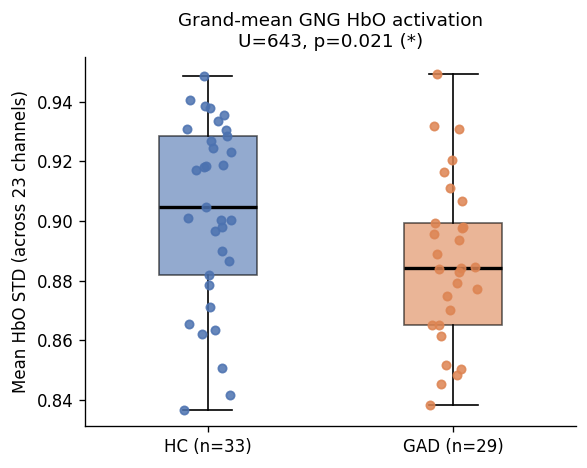

Saved: fig_task_grand_mean.png


In [10]:
hc_grand  = hc.mean(axis=1)
gad_grand = gad.mean(axis=1)
U_g, p_g = mannwhitneyu(hc_grand, gad_grand, alternative='two-sided')
print(f'Grand-mean HbO STD (avg across 23 channels):')
print(f'  HC  (n={len(hc_grand)}) : {hc_grand.mean():.4f} ± {hc_grand.std(ddof=1):.4f}')
print(f'  GAD (n={len(gad_grand)}): {gad_grand.mean():.4f} ± {gad_grand.std(ddof=1):.4f}')
print(f'  Mann-Whitney U={U_g:.0f}, p={p_g:.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
bp = ax.boxplot([hc_grand, gad_grand], patch_artist=True, widths=0.4,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#4C72B0', '#DD8452']):
    patch.set_facecolor(color); patch.set_alpha(0.6)
np.random.seed(0)
for i, (data, color) in enumerate(zip([hc_grand, gad_grand], ['#4C72B0','#DD8452']), 1):
    jitter = np.random.uniform(-0.1, 0.1, size=len(data))
    ax.scatter(np.full(len(data), i)+jitter, data, color=color, s=25, alpha=0.85, zorder=3)
ax.set_xticks([1,2]); ax.set_xticklabels([f'HC (n={len(HC_IDS)})', f'GAD (n={len(GAD_IDS)})'])
ax.set_ylabel('Mean HbO STD (across 23 channels)')
stars = '***' if p_g < 0.001 else ('**' if p_g < 0.01 else ('*' if p_g < 0.05 else 'ns'))
ax.set_title(f"Grand-mean GNG HbO activation\nU={U_g:.0f}, p={p_g:.3f} ({stars})")
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_task_grand_mean.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_task_grand_mean.png')


## 9. Summary & CSV Export

In [11]:
stats_df.insert(0, 'task', TASK)
out_csv = os.path.join(OUT_DIR, 'results_brain_activation_stats.csv')
stats_df.to_csv(out_csv, index=False, float_format='%.6f')
print(f'Saved: {out_csv}  (rows={len(stats_df)})')

print()
print('=' * 70)
print('  BRAIN ACTIVATION ANALYSIS SUMMARY (GNG)')
print('=' * 70)
print(f'Tests : Mann-Whitney U (two-sided), Benjamini-Hochberg FDR (q=0.05)')
print(f'Cohort: HC n={len(HC_IDS)}, GAD n={len(GAD_IDS)}')
print(f'Metric: per-channel STD across concatenated trials of HbO')
print()
print(f'  Channels p<0.05 (uncorrected): {stats_df["sig_raw"].sum()}/{N_CH}')
print(f'  Channels q<0.05 (FDR)         : {stats_df["sig_fdr"].sum()}/{N_CH}')
print()
top = stats_df.sort_values('p_raw').head(5)[['channel','p_raw','p_fdr','d']]
print('Top-5 channels by p_raw:')
print(top.to_string(index=False, float_format=lambda x: f'{x:.4g}'))
print()
print('Generated figures:')
for f in ['fig_topo_activation.png','fig_topo_effect_size.png',
          'fig_channel_task_heatmap.png','fig_gng_sig_channels.png','fig_task_grand_mean.png']:
    print(f'  - {f}')


Saved: /home/user/jeffrymahbuubi/PROJECTS/2-fNIRS-Graph-Base-Method/src/notebook/statistical-analysis/02_brain_activation/results_brain_activation_stats.csv  (rows=23)

  BRAIN ACTIVATION ANALYSIS SUMMARY (GNG)
Tests : Mann-Whitney U (two-sided), Benjamini-Hochberg FDR (q=0.05)
Cohort: HC n=33, GAD n=29
Metric: per-channel STD across concatenated trials of HbO

  Channels p<0.05 (uncorrected): 10/23
  Channels q<0.05 (FDR)         : 4/23

Top-5 channels by p_raw:
channel     p_raw   p_fdr       d
  S5_D5 0.0008701 0.01391 -0.9191
  S2_D1  0.001297 0.01391 -0.9248
  S3_D3  0.002309 0.01391 -0.7652
  S1_D1   0.00242 0.01391 -0.8129
  S3_D4    0.0111 0.05107 -0.6429

Generated figures:
  - fig_topo_activation.png
  - fig_topo_effect_size.png
  - fig_channel_task_heatmap.png
  - fig_gng_sig_channels.png
  - fig_task_grand_mean.png
